In [224]:
using ITensors
using ITensorMPS
using JLD2
using Plots
using LaTeXStrings
using Printf
using Polynomials
using Statistics
using GLM
using DataFrames





# File opening

In [ ]:


dmrg_data = Dict{Float64, Dict{Float64, Dict{String, Any}}}()
mpo_data = Dict{Float64, Dict{String, Any}}()
clean_fid_data = Dict{Float64, Dict{String, Any}}()

data_directory = joinpath(@__DIR__, "data")

if isdir(data_directory)
    for file in readdir(data_directory)
        if endswith(file, ".jld2")
            filepath = joinpath(data_directory, file)
            loaded_dict = load(filepath)

            if startswith(file, "data_fid_") && haskey(loaded_dict, "cutoff") && haskey(loaded_dict, "sigma")
                cutoff = loaded_dict["cutoff"]
                sigma = loaded_dict["sigma"]
                if !haskey(dmrg_data, cutoff)
                    dmrg_data[cutoff] = Dict{Float64, Dict{String, Any}}()
                end
                dmrg_data[cutoff][sigma] = loaded_dict

            elseif startswith(file, "mpo_scaling_data_") && haskey(loaded_dict, "sigma")
                sigma = loaded_dict["sigma"]
                mpo_data[sigma] = loaded_dict

            elseif startswith(file, "data_clean_fid_") && haskey(loaded_dict, "cutoff")
                cutoff = loaded_dict["cutoff"]
                clean_fid_data[cutoff] = loaded_dict
            end
        end
        println("Loaded data from file: $file")
    end
else
    println("Directory not found: $data_directory. Please check the path.")
end



Data successfully loaded. Generating plots...


# MPO Bond Dimension

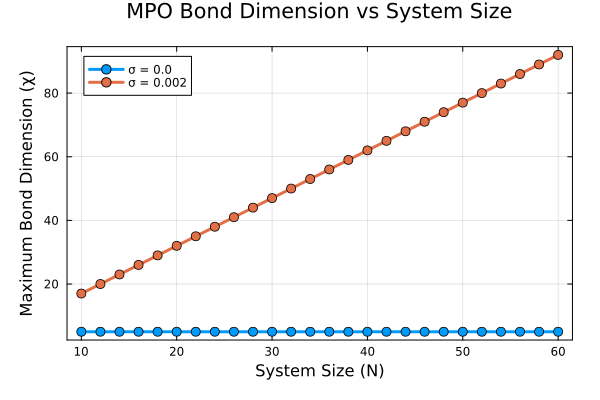

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\mpo_scaling.png"

In [ ]:


plot_sigmas = [0.0, 0.002] 
N_min = 10
N_max = 60

p = plot(
    title="MPO Bond Dimension vs System Size",
    xlabel="System Size (N)",
    ylabel="Maximum Bond Dimension (χ)",
    legend=:topleft,
    grid=true,
    framestyle=:box,
    size=(600, 400),
    margin=5 * Plots.mm
)

for sigma in plot_sigmas
    if haskey(mpo_data, sigma)
        data = mpo_data[sigma]
        
        mpo_bd_avg = data["mpo_bd_avg"]
        mpo_bd_err = data["mpo_bd_err"]
        N_range = data["N_range"]
        
        if sigma == 0.0
            mpo_bd_err = nothing
        end

        valid_indices = findall(n -> N_min <= n <= N_max, N_range)
        
        filtered_N = N_range[valid_indices]
        filtered_avg = mpo_bd_avg[valid_indices]
        filtered_err = isnothing(mpo_bd_err) ? nothing : mpo_bd_err[valid_indices]

        plot!(
            p, 
            filtered_N, 
            filtered_avg,
            # yerror=filtered_err,
            label="σ = $sigma",
            marker=:circle,
            markersize=5,
            linewidth=3
        )
    else
        println("Warning: Data for σ = $sigma not found in mpo_data. Skipping...")
    end
end

display(p)


savefig(p, joinpath(@__DIR__, "images_report", "mpo_scaling.png"))

# MPS

# Bond dimension - Clean


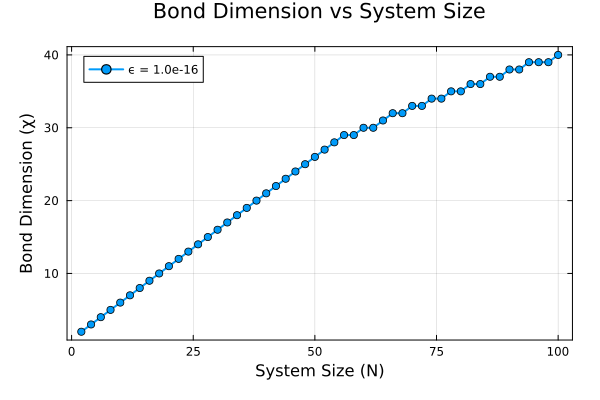

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\bd_trunc_clean.png"

In [229]:
target_sigma = 0.0
target_truncs = [1e-16]

p_bd = plot(
    title = "Bond Dimension vs System Size",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topleft,    
    size = (600, 400),
    margin = 5Plots.mm,
    grid=true,
    framestyle=:box
)

for trunc in target_truncs
    if haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        
        N_full = data["N_range"]
        bond_dims_full = data["avg_arr"]
        err_arr_full = data["err_arr"]
        
        mask = bond_dims_full .> 0
        N_vals = N_full[mask]
        bond_dims = bond_dims_full[mask]
        
        if target_sigma == 0.0
            err_bars = nothing
        else
            err_bars = err_arr_full[mask]
        end

        plot!(p_bd, N_vals, bond_dims, 
            yerror = err_bars,
            label = "ϵ = $(trunc)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for sigma = $target_sigma, Trunc = $truncation")
    end
end

display(p_bd)
savefig(p_bd, joinpath("images_report", "bd_trunc_clean.png"))

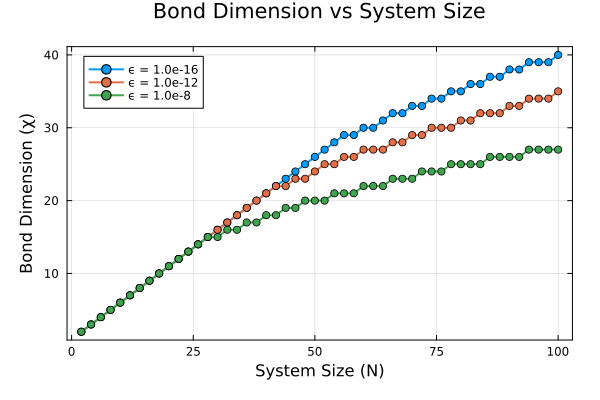

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\bd_truncs_clean.png"

In [230]:
target_sigma = 0.0
target_truncs = [1e-16, 1e-12, 1e-8]

p_bd = plot(
    title = "Bond Dimension vs System Size",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topleft,    
    size = (600, 400),
    margin = 5Plots.mm,
    grid=true,
    framestyle=:box
)

for trunc in target_truncs
    if haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        
        N_full = data["N_range"]
        bond_dims_full = data["avg_arr"]
        err_arr_full = data["err_arr"]
        
        mask = bond_dims_full .> 0
        N_vals = N_full[mask]
        bond_dims = bond_dims_full[mask]
        
        if target_sigma == 0.0
            err_bars = nothing
        else
            err_bars = err_arr_full[mask]
        end

        plot!(p_bd, N_vals, bond_dims, 
            yerror = err_bars,
            label = "ϵ = $(trunc)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for sigma = $target_sigma, Trunc = $truncation")
    end
end

display(p_bd)
savefig(p_bd, joinpath("images_report", "bd_truncs_clean.png"))

# Bond Dimension - Disordered

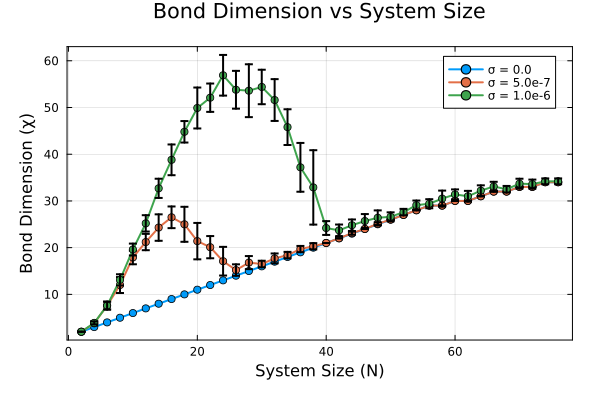

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\bd_dis.png"

In [ ]:
target_sigmas = [0.0, 5e-7, 1e-6] 
target_trunc = 1e-16
max_N = 76

p_bd = plot(
    title = "Bond Dimension vs System Size",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topright,    
    size = (600, 400),
    margin = 5Plots.mm,
    grid=true,
    framestyle=:box
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        bond_dims_full = data["avg_arr"]
        err_arr_full = data["err_arr"]
        
        mask = (bond_dims_full .> 0) .& (N_full .<= max_N)
        
        N_vals = N_full[mask]
        bond_dims = bond_dims_full[mask]
        
        if σ == 0.0
            err_bars = nothing
        else
            err_bars = err_arr_full[mask]
        end

        plot!(p_bd, N_vals, bond_dims, 
            yerror = err_bars,
            label = "σ = $(σ)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_bd)
savefig(p_bd, joinpath("images_report", "bd_dis.png"))

# Spectra - Clean

In [232]:
function unfold_spectrum(s)
    n_vals = length(s) 
    x_vals = zeros(Int, n_vals)
    y_vals = zeros(Float64, n_vals)

    if n_vals > 0
        x_vals[1] = 0 
        y_vals[1] = s[1]
    end

    for i in 2:n_vals
        step = div(i,2)
        sgn = iseven(i) ? 1 : -1
        x_vals[i] = sgn * step
        y_vals[i] = s[i]
    end

    perm = sortperm(x_vals)
    return x_vals[perm], y_vals[perm]
end


function get_unfolded_data(raw_spectra)
    valid_spectra = filter(x -> x > 0, raw_spectra)
    isempty(valid_spectra) && return Float64[], Float64[]
    return unfold_spectrum(sort(valid_spectra, rev=true))
end

get_unfolded_data (generic function with 1 method)

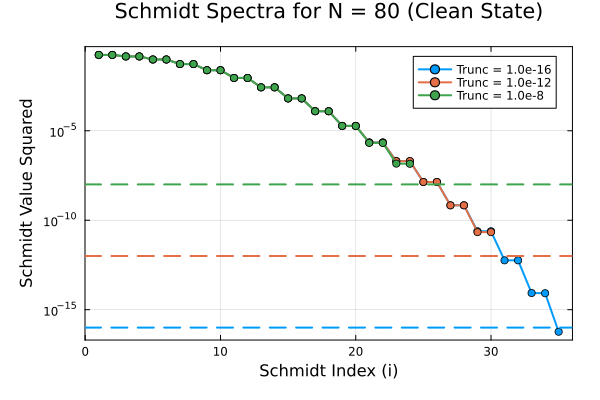

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\spectra_clean_truncations_N=80.png"

In [253]:
target_truncs = [1e-16, 1e-12, 1e-8]
target_sigma = 0.0
target_N = 80

p_spectra = plot(
    title = "Schmidt Spectra for N = $target_N (Clean State)",
    xlabel = "Schmidt Index (i)",
    ylabel = "Schmidt Value Squared",
    legend = :topright,
    yscale = :log10,
    size = (600, 400),
    margin = 5Plots.mm,
    grid=true,
    framestyle=:box
)

for (i, trunc) in enumerate(target_truncs)
    if haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        
        N_full = data["N_range"]
        idx = findfirst(==(target_N), N_full)
        
        if !isnothing(idx)
            spectra_full = haskey(data, "spectra") ? data["spectra"] : data["spectra_avg"]
            spectra_vals = spectra_full[idx, :]
            
            valid_spectra = filter(x -> x > 0, spectra_vals)
            sorted_spectra = sort(valid_spectra, rev=true)
            
            plot!(p_spectra, 1:length(sorted_spectra), sorted_spectra, 
                label = "Trunc = $(trunc)", 
                marker = :circle, 
                linewidth = 2,
                color = i)
                
            # Plot the horizontal truncation line with the matching colour
            hline!(p_spectra, [trunc], 
                label = "", 
                linestyle = :dash, 
                linewidth = 2,
                color = i)
        else
            println("Warning: N = $target_N not found for Trunc = $trunc")
        end
    else
        println("Warning: Data not found for Trunc = $trunc, σ = $target_sigma")
    end
end

display(p_spectra)
savefig(p_spectra, joinpath("images", "spectra_clean_truncations_N=$target_N.png"))

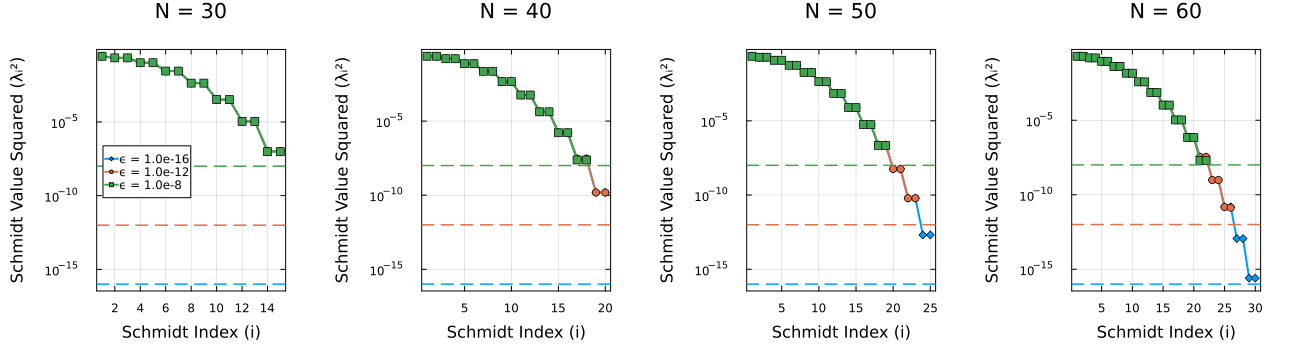

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\spectra_clean_truncations_1x4.png"

In [ ]:
target_truncs = [1e-16, 1e-12, 1e-8]
target_sigma = 0.0
target_Ns = [30, 40, 50, 60]

subplots = []

for (j, target_N) in enumerate(target_Ns)
    p_sub = plot(
        title = "N = $target_N",
        xlabel = "Schmidt Index (i)",
        ylabel = "Schmidt Value Squared (λᵢ²)",
        legend = j == 1 ? :left : false, 
        yscale = :log10,
        grid = true
    )
    
    for (i, trunc) in enumerate(target_truncs)
        if haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma)
            data = all_data[trunc][target_sigma]
            
            N_full = data["N_range"]
            idx = findfirst(==(target_N), N_full)
            
            if !isnothing(idx)
                spectra_full = haskey(data, "spectra") ? data["spectra"] : data["spectra_avg"]
                spectra_vals = spectra_full[idx, :]
                
                valid_spectra = filter(x -> x > 0, spectra_vals)
                sorted_spectra = sort(valid_spectra, rev=true)
                
                markerstyle = i == 1 ? :diamond : i ==2  ? :circle : :square

                plot!(p_sub, 1:length(sorted_spectra), sorted_spectra, 
                    label = j == 1 ? "ϵ = $(trunc)" : "", 
                    marker = markerstyle, 
                    linewidth = 2,
                    color = i)
                    
                hline!(p_sub, [trunc], 
                    label = "", 
                    linestyle = :dash, 
                    linewidth = 1.5,
                    color = i)
            else
                println("Warning: N = $target_N not found for Trunc = $trunc")
            end
        else
            println("Warning: Data not found for Trunc = $trunc, σ = $target_sigma")
        end
    end
    
    push!(subplots, p_sub)
end

p_spectra = plot(subplots..., 
    layout = (1, 4), 
    size = (1300, 350), 
    # plot_title = "Schmidt Spectra Across Varying System Sizes",
    margin = 8Plots.mm,
    grid=true,
    framestyle=:box
)

display(p_spectra)
savefig(p_spectra, joinpath("images_report", "spectra_clean_truncations_1x4.png"))

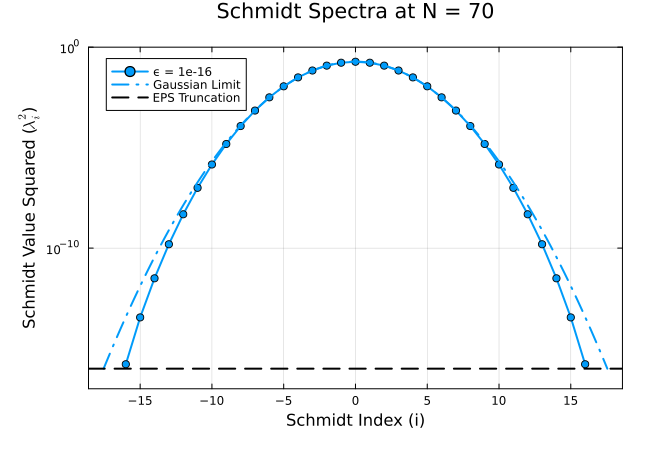

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\Schmidt_spectra_gaussian_clean.png"

In [ ]:

target_sigmas = [0.0, 1e-6] 
target_trunc = 1e-16
target_N = 70

p_spectra = plot(
    title = "Schmidt Spectra at N = $target_N",
    xlabel = "Schmidt Index (i)",
    ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
    legend = :topleft,
    yscale = :log10,
    size = (650, 450),
    margin = 5 * Plots.mm,
    ylims = (1e-17, 1.0),
    grid = true,
    framestyle = :box
)

clean_spectra = Float64[]
disordered_spectra = Float64[]

# dictionary lookups
if haskey(all_data, target_trunc)
    trunc_data = all_data[target_trunc]
    
    if haskey(trunc_data, 0.0)
        idx_clean = findfirst(==(target_N), trunc_data[0.0]["N_range"])
        if !isnothing(idx_clean)
            clean_spectra = trunc_data[0.0]["spectra_avg"][idx_clean, :]
        end
    end
    
    if haskey(trunc_data, 1e-6)
        idx_dis = findfirst(==(target_N), trunc_data[1e-6]["N_range"])
        if !isnothing(idx_dis)
            disordered_spectra = trunc_data[1e-6]["spectra_avg"][idx_dis, :]
        end
    end
end

# residual spectra using zip and array comprehension
residual_spectra = Float64[]
if !isempty(clean_spectra) && !isempty(disordered_spectra)
    residual_spectra = [d for (d, c) in zip(disordered_spectra, clean_spectra) 
                        if d > 0.0 && (c == 0.0 || (d / c) > 10.0)]
else
    println("Warning: Could not compute residual. Missing clean or disordered data.")
end

function get_unfolded_data(raw_spectra)
    valid_spectra = filter(x -> x > 0, raw_spectra)
    if isempty(valid_spectra)
        return Float64[], Float64[]
    end
    return unfold_spectrum(sort(valid_spectra, rev=true))
end

function analytical_dicke_gaussian(N::Int, min_limit::Float64)
    sigma_sq = N / 16.0
    amp = 4.0 / sqrt(2.0 * pi * N)
    
    if min_limit >= amp
        return Float64[], Float64[]
    end
    
    x_max = sqrt(-2.0 * sigma_sq * log(min_limit / amp))
    x_smooth = collect(range(-x_max, x_max, length=500))
    
    gauss_y = amp .* exp.(.-(x_smooth.^2) ./ (2 * sigma_sq))
    
    return x_smooth, gauss_y
end

x_clean, y_clean = get_unfolded_data(clean_spectra)
x_dis, y_dis = get_unfolded_data(disordered_spectra)
x_res, y_res = get_unfolded_data(residual_spectra)

if !isempty(x_clean)
    plot!(p_spectra, x_clean, y_clean, label = "ϵ = 1e-16", marker = :circle, color = 1, linewidth = 2)
end

x_theory, y_theory = analytical_dicke_gaussian(target_N, target_trunc)
if !isempty(x_theory)
    plot!(p_spectra, x_theory, y_theory, 
        label = "Gaussian Limit", 
        linestyle = :dashdot, 
        color = 1, 
        linewidth = 2)
end

hline!(p_spectra, [target_trunc], 
    label = "EPS Truncation", 
    linestyle = :dash, 
    linecolor = :black, 
    linewidth = 2)

display(p_spectra)

savefig(p_spectra, joinpath("images_report", "Schmidt_spectra_gaussian_clean.png"))

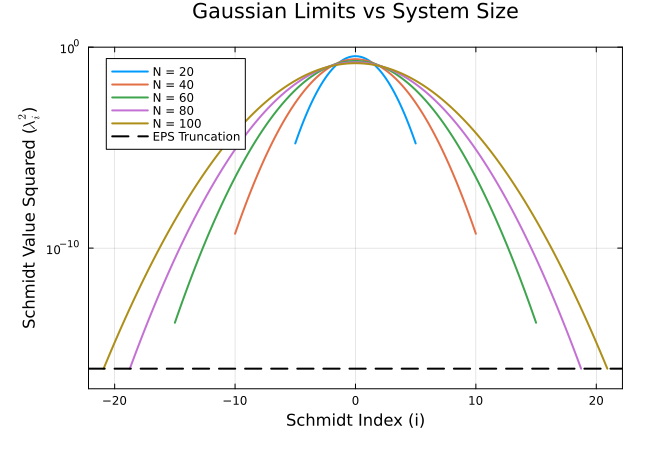

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\Gaussian_limits_scaling.png"

In [259]:

target_trunc = 1e-16
target_Ns = [20, 40, 60, 80, 100]

p_gauss = plot(
    title = "Gaussian Limits vs System Size",
    xlabel = "Schmidt Index (i)",
    ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
    legend = :topleft,
    yscale = :log10,
    size = (650, 450),
    margin = 5 * Plots.mm,
    ylims = (1e-17, 1.0),
    grid = true,
    framestyle = :box
)

function analytical_dicke_gaussian(N::Int, min_limit::Float64)
    sigma_sq = N / 16.0
    amp = 4.0 / sqrt(2.0 * pi * N)
    
    if min_limit >= amp
        return Float64[], Float64[]
    end
    
    x_eps = sqrt(-2.0 * sigma_sq * log(min_limit / amp))
    

    x_physical = N / 4.0 
    
    x_max = min(x_eps, x_physical)
    
    x_smooth = collect(range(-x_max, x_max, length=500))
    
    gauss_y = amp .* exp.(.-(x_smooth.^2) ./ (2 * sigma_sq))
    
    gauss_y = max.(gauss_y, min_limit)
    
    return x_smooth, gauss_y
end

for N in target_Ns
    x_theory, y_theory = analytical_dicke_gaussian(N, target_trunc)
    
    if !isempty(x_theory)
        plot!(p_gauss, x_theory, y_theory, 
            label = "N = $N", 
            linewidth = 2)
    end
end

hline!(p_gauss, [target_trunc], 
    label = "EPS Truncation", 
    linestyle = :dash, 
    linecolor = :black, 
    linewidth = 2)

display(p_gauss)


savefig(p_gauss, joinpath("images_report", "Gaussian_limits_scaling.png"))

# Spectra - Disordered

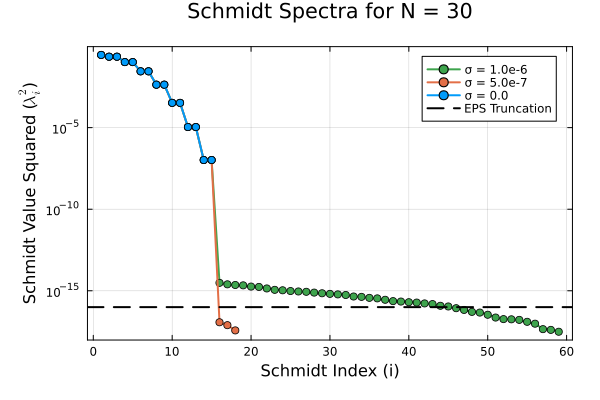

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\spectra_dis_N=30.png"

In [236]:
target_sigmas = [0.0, 5e-7, 1e-6] 
target_trunc = 1e-16
target_N = 30

p_spectra = plot(
    title = "Schmidt Spectra for N = $target_N",
    xlabel = "Schmidt Index (i)",
    ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
    legend = :topright,
    yscale = :log10,
    size = (600, 400),
    margin = 5Plots.mm,
    grid=true,
    framestyle=:box
)

for σ in sort(target_sigmas, rev=true) 
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        
        idx = findfirst(==(target_N), N_full)
        
        if !isnothing(idx)
            spectra = data["spectra_avg"][idx, :]
            
            valid_spectra = filter(x -> x > 0, spectra)
            
            sorted_spectra = sort(valid_spectra, rev=true)

            if σ == 0.0
                palette_idx = 1
            elseif σ == 5e-7
                palette_idx = 2 
            else
                palette_idx = 3  
            end
            
            plot!(p_spectra, 1:length(sorted_spectra), sorted_spectra, 
                label = "σ = $(σ)", 
                marker = :circle, 
                color = palette_idx,
                linewidth = 2)
        else
            println("Warning: N = $target_N not found for Trunc = $target_trunc, σ = $σ")
        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

hline!(p_spectra, [1e-16], label = "EPS Truncation", linestyle = :dash, color = :black, linewidth = 2)

display(p_spectra)
savefig(p_spectra, joinpath("images_report", "spectra_dis_N=$target_N.png"))

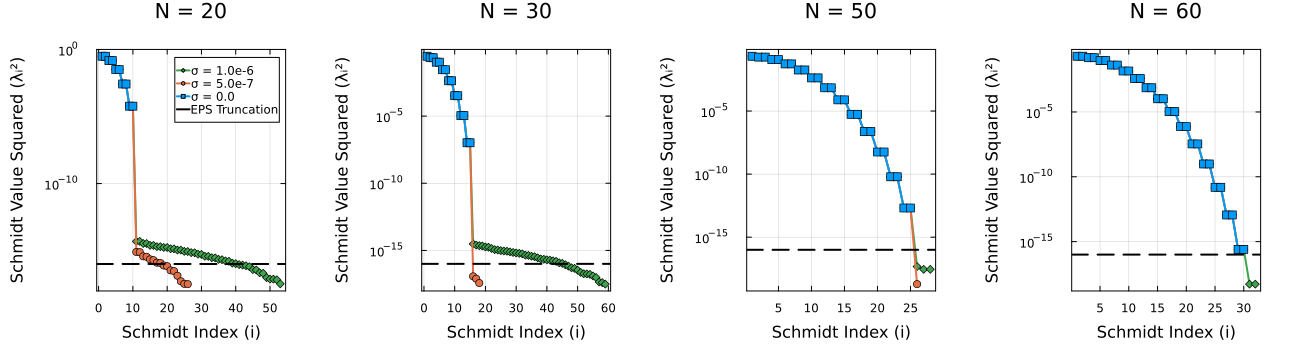

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\spectra_dis_1x4.png"

In [237]:
target_trunc = 1e-16
target_sigmas = [0.0, 5e-7, 1e-6]
target_Ns = [20, 30, 50, 60]

subplots = []

for (j, target_N) in enumerate(target_Ns)
    p_sub = plot(
        title = "N = $target_N",
        xlabel = "Schmidt Index (i)",
        ylabel = "Schmidt Value Squared (λᵢ²)",
        legend = j == 1 ? :topright : false, 
        yscale = :log10,
        
        grid=true,
        framestyle=:box
    )
    
    for (i, sigma) in enumerate(sort(target_sigmas, rev = true))
        # Check for the fixed truncation and current sigma
        if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], sigma)
            data = all_data[target_trunc][sigma]
            
            N_full = data["N_range"]
            idx = findfirst(==(target_N), N_full)
            
            if !isnothing(idx)
                spectra_full = haskey(data, "spectra") ? data["spectra"] : data["spectra_avg"]
                spectra_vals = spectra_full[idx, :]
                
                valid_spectra = filter(x -> x > 0, spectra_vals)
                sorted_spectra = sort(valid_spectra, rev=true)
                
                markerstyle = i == 1 ? :diamond : i == 2 ? :circle : :square


                if sigma == 0.0
                    palette_idx = 1
                elseif sigma == 5e-7
                    palette_idx = 2 
                else
                    palette_idx = 3  
                end

                # Plot the spectra using 'i' for colour index to keep it consistent
                plot!(p_sub, 1:length(sorted_spectra), sorted_spectra, 
                    label = j == 1 ? "σ = $(sigma)" : "", 
                    marker = markerstyle, 
                    linewidth = 2,
                    color = palette_idx)
            else
                println("Warning: N = $target_N not found for σ = $sigma")
            end
        else
            println("Warning: Data not found for Trunc = $target_trunc, σ = $sigma")
        end
    end
    
    # Plot the single horizontal truncation line in black for this subplot
    hline!(p_sub, [target_trunc], 
        label = j == 1 ? "EPS Truncation" : "", 
        linestyle = :dash, 
        linewidth = 2,
        color = :black)
        
    push!(subplots, p_sub)
end

# Combine into a 1x4 grid, adjust size for horizontal span, add margins
p_spectra = plot(subplots..., 
    layout = (1, 4), 
    size = (1300, 350), 
    margin = 8Plots.mm
)

display(p_spectra)
savefig(p_spectra, joinpath("images_report", "spectra_dis_1x4.png"))

# Entropies - Clean


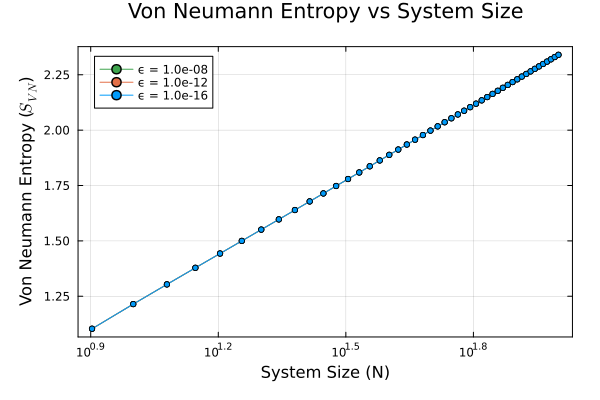

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\S_VN_clean_log.png"

In [238]:
p_vn = plot(
    title = "Von Neumann Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Von Neumann Entropy ($S_{VN}$)",
    legend = :topleft,
    xaxis = :log10,
    grid=true,
    framestyle=:box,
    size = (600, 400),
    margin = 5Plots.mm
)

target_sigma = 0.0
chosen_truncs = [1e-16, 1e-12, 1e-8]
start_N = 8 # Define your starting N here

for trunc in sort(chosen_truncs, rev = true)
    if haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        
        # Generate the full range
        N_range_full = collect(2:2:length(data["vn_avg"])*2) 
        
        # Find indices where N is greater than or equal to start_N
        valid_indices = findall(x -> x >= start_N, N_range_full)
        
        # Filter the arrays using the valid indices
        N_range = N_range_full[valid_indices]
        vn_avg = data["vn_avg"][valid_indices]
        vn_err = data["vn_err"][valid_indices]

        if trunc == 1e-16
            coloridx = 1
        elseif trunc == 1e-12
            coloridx = 2
        else
            coloridx = 3
        end
        
        plot!(p_vn, N_range, vn_avg, 
              ribbon = vn_err,
              label = "ϵ = $(@sprintf("%.1e", trunc))",
              color = coloridx,
              marker = :circle, markersize = 3)
    end
end

display(p_vn)
savefig(p_vn, joinpath("images_report", "S_VN_clean_log.png"))

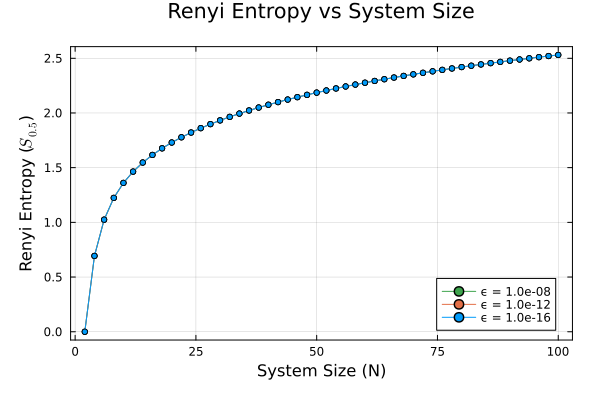

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\S_05_clean.png"

In [239]:
# Plotting Renyi Entropy (alpha=0.5) for multiple truncations
p_s05 = plot(
    title = "Renyi Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Renyi Entropy ($S_{0.5}$)",
    legend = :bottomright,
    grid=true,
    framestyle=:box,
    size = (600, 400),
    margin = 5Plots.mm
)

for trunc in sort(chosen_truncs, rev = true)
    if haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        N_range = collect(2:2:length(data["s05_avg"])*2)
        
        if trunc == 1e-16
            coloridx = 1
        elseif trunc == 1e-12
            coloridx = 2
        else
            coloridx = 3
        end

        plot!(p_s05, N_range, data["s05_avg"], 
              ribbon = data["s05_err"],
              label = "ϵ = $(@sprintf("%.1e", trunc))",
              color = coloridx,
              marker = :circle, markersize = 3)
    end
end

display(p_s05)
savefig(p_s05, joinpath("images_report", "S_05_clean.png"))

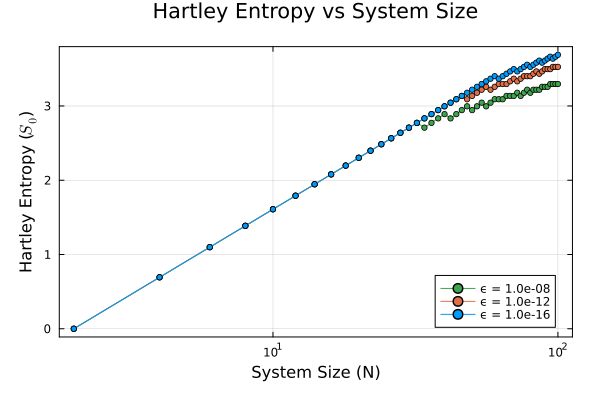

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\S_0_clean.png"

In [240]:
# Plotting Hartley Entropy (alpha=0) for multiple truncations
p_s0 = plot(
    title = "Hartley Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Hartley Entropy ($S_{0}$)",
    legend = :bottomright,
    xaxis = :log10,
    grid=true,
    framestyle=:box,
    size = (600, 400),
    margin = 5Plots.mm
)

for trunc in sort(chosen_truncs, rev = true)
    if haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        N_range = collect(2:2:length(data["s0_avg"])*2)
        

        if trunc == 1e-16
            coloridx = 1
        elseif trunc == 1e-12
            coloridx = 2
        else
            coloridx = 3
        end


        plot!(p_s0, N_range, data["s0_avg"], 
              ribbon = data["s0_err"],
              label = "ϵ = $(@sprintf("%.1e", trunc))",
              color = coloridx,
              marker = :circle, markersize = 3)
    end
end

display(p_s0)
savefig(p_s0, joinpath("images_report", "S_0_clean.png"))

# Entropies - Disordered

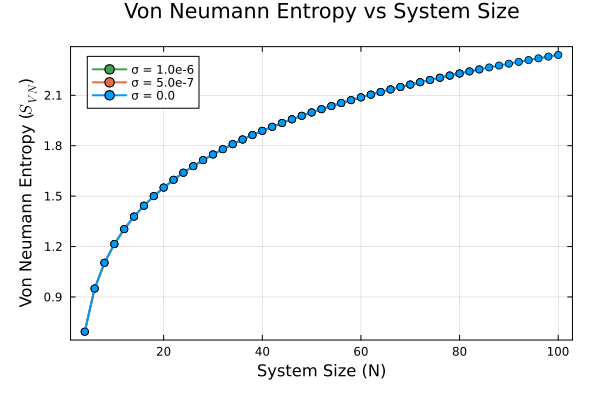

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\ent_vn_dis.png"

In [241]:
target_sigmas = [0.0, 5e-7, 1e-6] 
target_trunc = 1e-16

p_vn = plot(
    title = "Von Neumann Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Von Neumann Entropy ($S_{VN}$)",
    legend = :topleft,    
    # xscale = :log10,
    size = (600, 400),
    margin = 5Plots.mm,
    grid=true,
    framestyle=:box
)

for σ in sort(target_sigmas, rev = true)
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_range = data["N_range"]
        vn_entropy = data["vn_avg"]

        mask = vn_entropy .> 0.0
        
        valid_N = N_range[mask]
        valid_vn = vn_entropy[mask]

        
        if σ == 0.0
            palette_idx = 1
        elseif σ == 5e-7
            palette_idx = 2 
        else
            palette_idx = 3  
        end
    
        if !isempty(valid_vn)
            plot!(p_vn, valid_N, valid_vn, 
                label = "σ = $(σ)", 
                marker = :circle, 
                color = palette_idx,
                linewidth = 2)

        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_vn)
savefig(p_vn, joinpath("images_report", "ent_vn_dis.png"))

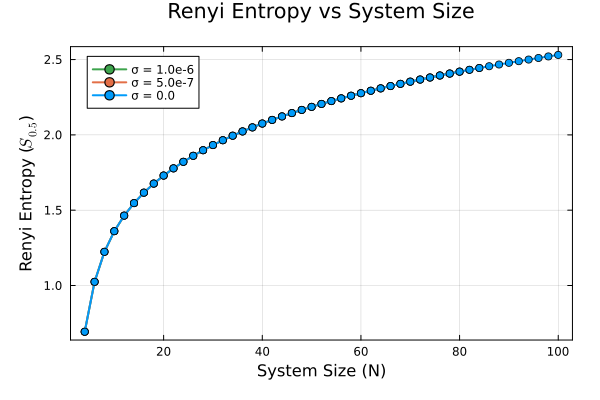

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\ent_s05_dis.png"

In [242]:
target_sigmas = [0.0, 5e-7,1e-6] 
target_trunc = 1e-16

p_s05 = plot(
    title = "Renyi Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Renyi Entropy ($S_{0.5}$)",
    legend = :topleft,    
    # xscale = :log10,
    size = (600, 400),
    margin = 5Plots.mm,
    grid=true,
    framestyle=:box
)

for σ in sort(target_sigmas, rev = true)
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_range = data["N_range"]
        s05_entropy = data["s05_avg"]

        mask = s05_entropy .> 0.0
        
        valid_N = N_range[mask]
        valid_ent = s05_entropy[mask]

        if σ == 0.0
            palette_idx = 1
        elseif σ == 5e-7
            palette_idx = 2 
        else
            palette_idx = 3  
        end
        
        if !isempty(valid_ent)
            plot!(p_s05, valid_N, valid_ent, 
                label = "σ = $(σ)", 
                marker = :circle, 
                color = palette_idx,
                linewidth = 2)

        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_s05)
savefig(p_s05, joinpath("images_report", "ent_s05_dis.png"))

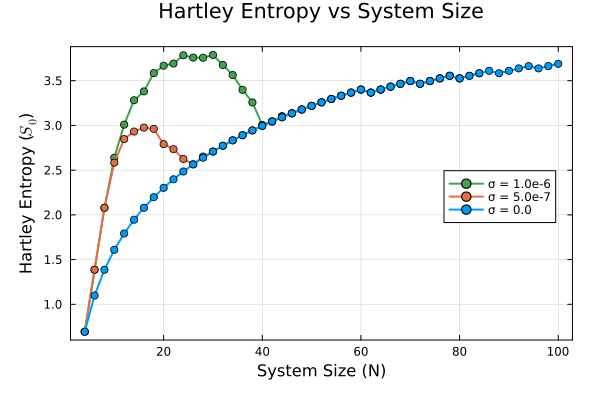

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\ent_s0_dis.png"

In [243]:
target_sigmas = [0.0, 5e-7, 1e-6]
target_trunc = 1e-16

p_s0 = plot(
    title = "Hartley Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Hartley Entropy ($S_0$)",
    legend = :right,    
    # xscale = :log10,
    # yscale = :log10,
    size = (600, 400),
    margin = 5Plots.mm,
    grid=true,
    framestyle=:box
)

for σ in sort(target_sigmas, rev = true)
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_range = data["N_range"]
        s0_entropy = data["s0_avg"]

        mask = s0_entropy .> 0.0
        
        valid_N = N_range[mask]
        valid_ent = s0_entropy[mask]

        if σ == 0.0
            palette_idx = 1
        elseif σ == 5e-7
            palette_idx = 2 
        else
            palette_idx = 3  
        end
        
        if !isempty(valid_ent)
            plot!(p_s0, valid_N, valid_ent, 
                label = "σ = $(σ)", 
                marker = :circle, 
                color = palette_idx,
                linewidth = 2)

        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_s0)
savefig(p_s0, joinpath("images_report", "ent_s0_dis.png"))

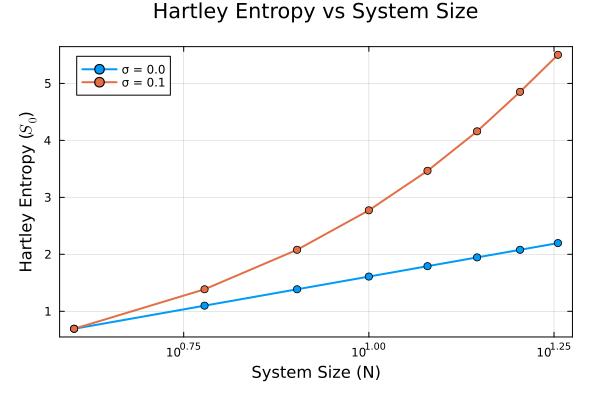

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\ent_s0_zoom.png"

In [244]:
target_sigmas = [0.0, 1e-1] 
target_trunc = 1e-16
target_N_range = 2:18

p_s0 = plot(
    title = "Hartley Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Hartley Entropy ($S_0$)",
    legend = :topleft,    
    xscale = :log10,
    size = (600, 400),
    margin = 5Plots.mm,
    grid=true,
    framestyle=:box
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        data_N = data["N_range"]
        s0_entropy = data["s0_avg"]

        mask = (s0_entropy .> 0.0) .& in.(data_N, Ref(target_N_range))
        
        valid_N = data_N[mask]
        valid_ent = s0_entropy[mask]

        if σ != 0.0
            palette_idx = 2  
        else
            palette_idx = 1
        end
        
        if !isempty(valid_ent)
            plot!(p_s0, valid_N, valid_ent, 
                label = "σ = $(σ)", 
                marker = :circle, 
                color = palette_idx,
                linewidth = 2)

        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_s0)
savefig(p_s0, joinpath("images_report", "ent_s0_zoom.png"))

# infidelity - Clean


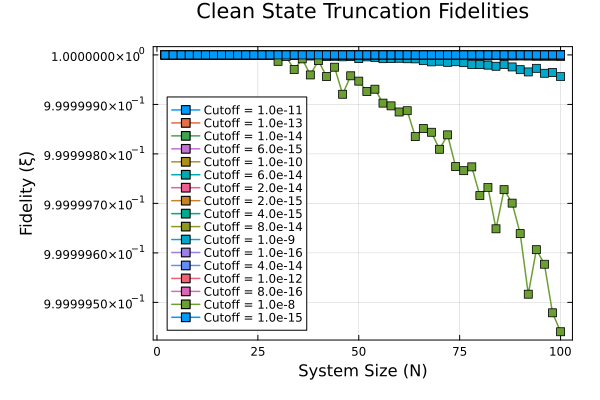

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\fid_clean_truncations.png"

In [245]:

p_clean = plot(
    title = "Clean State Truncation Fidelities", 
    xlabel = "System Size (N)", 
    ylabel = "Fidelity (ξ)", 
    legend = :bottomleft,
    grid = true,
    framestyle = :box,
    size = (600, 400),
    margin = 5 * Plots.mm
)
                   
for (cutoff, data) in clean_fid_data
    plot!(
        p_clean, 
        data["N_range"], 
        data["fidelities"], 
        label = "Cutoff = $cutoff", 
        marker = :square,
        markersize = 4,
        linewidth = 1.5
    )
end

display(p_clean)
savefig(p_clean, joinpath(@__DIR__, "images_report", "fid_clean_truncations.png"))



In [ ]:


function get_clean_infidelity_data(clean_dict, target_trunc)
    if haskey(clean_dict, target_trunc)
        data = clean_dict[target_trunc]
        N_vals = data["N_range"]
        xi_vals = data["fidelities"]
        
        # Calculate infidelity, beta = √(1 - ξ²)
        # max is used to prevent DomainError from minor floating point inaccuracies
        beta_vals = sqrt.(max.(0.0, 1.0 .- xi_vals.^2))
        
        return N_vals, beta_vals
    else
        @warn "Data not found for Trunc = $target_trunc"
        return nothing, nothing
    end
end



get_clean_infidelity_data (generic function with 1 method)

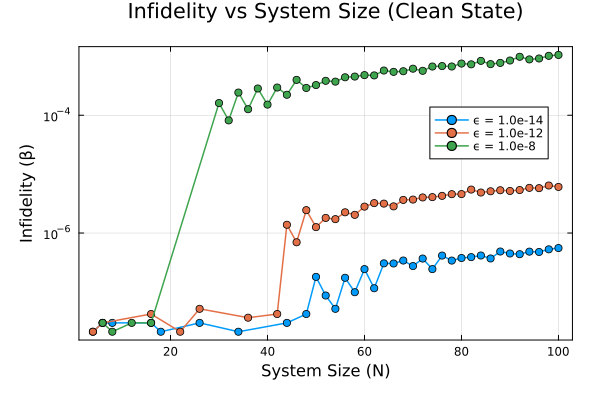

In [274]:


target_truncs = [1e-14, 1e-12, 1e-8]

p_infid = plot(
    title = "Infidelity vs System Size (Clean State)",
    xlabel = "System Size (N)",
    ylabel = "Infidelity (β)",
    legend = (0.8, 0.75), 
    yscale = :log10, 
    grid = true,
    framestyle = :box,
    size = (600, 400),
    margin = 5 * Plots.mm
)

for trunc in target_truncs
    N_vals, beta_vals = get_clean_infidelity_data(clean_fid_data, trunc)
    
    if !isnothing(N_vals)
        # Log scale plots cannot handle 0.0, so filter for strictly positive values
        # We use a small threshold to filter out numerical noise close to exactly zero
        valid_mask = beta_vals .> 1e-15
        
        if any(valid_mask)
            plot!(
                p_infid, 
                N_vals[valid_mask], 
                beta_vals[valid_mask], 
                label = "ϵ = $(trunc)", 
                marker = :circle, 
                markersize = 4,
                linewidth = 1.5
            )
        else
            println("Note: Infidelity is effectively 0.0 for all N at Trunc = $trunc")
        end
    end
end

display(p_infid)
# savefig(p_infid, joinpath(@__DIR__, "images_report", "infid_clean_truncations.png"))

# Infidelities - Disordered

In [248]:



"""
    get_infidelity_data(all_data, target_trunc, target_sigma)

Extracts system size (N), infidelity (beta), and error bars (if applicable) for a specific 
truncation and sigma from the loaded data dictionary.
"""
function get_infidelity_data(all_data, target_trunc, target_sigma)
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], target_sigma)
        data = all_data[target_trunc][target_sigma]
        
        N_full = data["N_range"]
        
        # 1. Handle Key Changes for Bond Dimensions (used for masking)
        bd_key = haskey(data, "bond_dims") ? "bond_dims" : "avg_arr"
        mask = data[bd_key] .> 0 
        
        N_vals = N_full[mask]
        
        # 2. Handle Key Changes for Fidelity
        fid_key = haskey(data, "fidelities") ? "fidelities" : "fid_avg"
        xi_vals = data[fid_key][mask] 
        
        # Calculate infidelity (beta)
        beta_vals = sqrt.(max.(0.0, 1.0 .- xi_vals.^2))
        
        # 3. Handle Errors (Only present in noisy/averaged data)
        if haskey(data, "fid_err")
            xi_errs = data["fid_err"][mask] 
            beta_errs = Float64[]
            for (x, b, dx) in zip(xi_vals, beta_vals, xi_errs)
                if b > 1e-10
                    push!(beta_errs, (x / b) * dx)
                else
                    push!(beta_errs, 0.0) 
                end
            end
            return N_vals, beta_vals, beta_errs
        else
            # Clean states have no standard deviation/error
            return N_vals, beta_vals, nothing 
        end
    else
        @warn "Data not found for Trunc = $target_trunc, σ = $target_sigma"
        return nothing
    end
end

get_infidelity_data

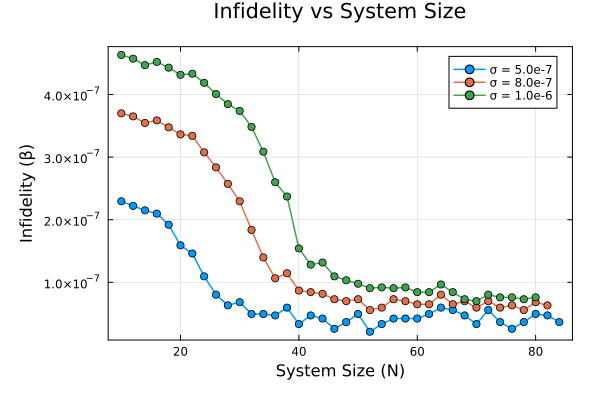

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\infid_dis.png"

In [249]:
target_trunc = 1e-16
chosen_sigmas = [5e-7, 8e-7, 1e-6]
min_N = 10
p_infid = plot(
    title = "Infidelity vs System Size",
    xlabel = "System Size (N)",
    ylabel = "Infidelity (β)",
    legend = :topright,
    grid=true,
    framestyle=:box,
    size = (600, 400),
    margin = 5Plots.mm
)

for σ in chosen_sigmas
    result = get_infidelity_data(all_data, target_trunc, σ)
    if !isnothing(result)
        N_vals, beta_vals, beta_errs = result
        
        # Filter data to start from min_N
        mask = N_vals .>= min_N
        N_filtered = N_vals[mask]
        beta_filtered = beta_vals[mask]
        # beta_errs_filtered = beta_errs[mask] # Uncomment if using yerror

        plot!(p_infid, N_filtered, beta_filtered, 
            # yerror = beta_errs_filtered,
            label = "σ = $σ", 
            marker = :circle, 
            markersize = 4,
            linewidth = 1.5)
    end
end

display(p_infid)
savefig(p_infid, joinpath("images_report", "infid_dis.png"))

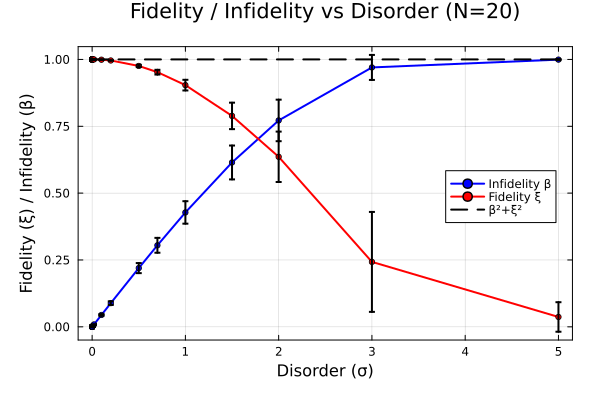

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\fid_inf_vs_sigma_N=20.png"

In [250]:

target_N = 20
target_trunc = 1e-16

βs = Float64[]
ξs = Float64[]
β_errs = Float64[]
ξ_errs = Float64[]
valid_σs = Float64[]

if haskey(all_data, target_trunc)
    available_sigmas = sort(collect(keys(all_data[target_trunc])))
    
    for σ in available_sigmas
        data = all_data[target_trunc][σ]
        
        if haskey(data, "N_range")
            N_range = data["N_range"]
            idx = findfirst(x -> x == target_N, N_range)
            
            if !isnothing(idx)

                xi_val = data["fid_avg"][idx]
                xi_err = haskey(data, "fid_err") ? data["fid_err"][idx] : 0.0
                

                result = get_infidelity_data(all_data, target_trunc, σ)
                
                if !isnothing(result)
                    N_vals, beta_vals, beta_errors = result
                    b_idx = findfirst(x -> x == target_N, N_vals)
                    
                    if !isnothing(b_idx)
                        push!(valid_σs, σ)
                        push!(ξs, xi_val)
                        push!(ξ_errs, xi_err)
                        push!(βs, beta_vals[b_idx])
                        push!(β_errs, beta_errors[b_idx])
                    end
                end
            end
        end
    end
    
    if !isempty(valid_σs)
        p1 = plot(
            title = "Fidelity / Infidelity vs Disorder (N=$target_N)",
            xlabel = "Disorder (σ)", 
            ylabel = "Fidelity (ξ) / Infidelity (β)",
            legend = :right, 
            grid=true,
            framestyle=:box,
            size = (600, 400),
            margin = 5Plots.mm
        )
             
        # Plot Infidelity (β)
        plot!(p1, valid_σs, βs, yerr=β_errs, 
              label="Infidelity β", color=:blue, marker=:circle, markersize=3, linewidth=2)
        
        # Plot Fidelity (ξ)
        plot!(p1, valid_σs, ξs, yerr=ξ_errs, 
              label="Fidelity ξ", color=:red, marker=:circle, markersize=3, linewidth=2)
              
        # Verify β^2 + ξ^2 = 1
        sq_sum = [β^2 + ξ^2 for (β, ξ) in zip(βs, ξs)]
        plot!(p1, valid_σs, sq_sum, label="β²+ξ²", color=:black, linewidth=2, linestyle=:dash)

        display(p1)
    else
        println("No valid data found for N = $target_N at Truncation $target_trunc.")
    end
else
    println("Data for Truncation $target_trunc not found.")
end

savefig(p1, joinpath("images_report", "fid_inf_vs_sigma_N=$target_N.png"))

# K-Band Logic

In [282]:
function get_corrected_k_levels(N::Int, σ::Float64, c::Float64)
    c_sigma = c * σ
    w0 = 1.0
    w2 = c_sigma^2
    w4 = c_sigma^4 / 2.0
    w6 = c_sigma^6 / 6.0
    
    total_w = w0 + w2 + w4 + w6
    
    return (
        k0 = (w0 / total_w) / 1.0,
        k2 = (w2 / total_w) / binomial(N, 2),
        k4 = (w4 / total_w) / binomial(N, 4),
        k6 = (w6 / total_w) / binomial(N, 6)
    )
end

function get_sorted_data(raw_spectra)
    sorted_spectra = sort(filter(>(0.0), raw_spectra), rev=true)
    return isempty(sorted_spectra) ? (Float64[], Float64[]) : (collect(1:length(sorted_spectra)), sorted_spectra)
end

function get_sorted_data_truncated(raw_spectra, threshold)
    sorted_spectra = sort(filter(>(threshold), raw_spectra), rev=true)
    return isempty(sorted_spectra) ? (Float64[], Float64[]) : (collect(1:length(sorted_spectra)), sorted_spectra)
end

get_sorted_data_truncated (generic function with 1 method)

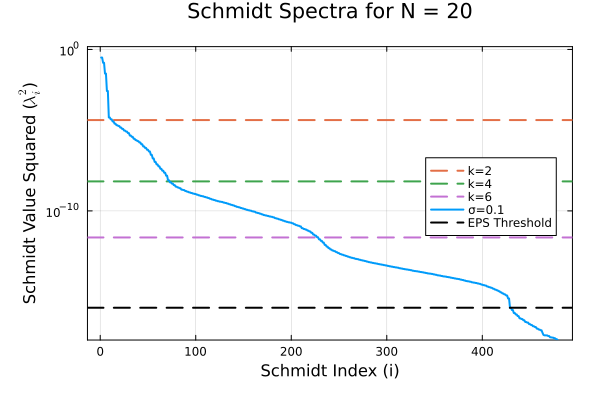

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\Schmidt_k_bands.png"

In [324]:

chosen_N = 20
disorder_sigma = 1e-1
target_trunc = 1e-16
c_leakage = 0.9



p1 = plot(
    title = "Schmidt Spectra for N = $chosen_N",
    xlabel = "Schmidt Index (i)",
    ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
    legend = :right,
    yscale = :log10,
    ylims = (1e-18, 1.5), 
    grid = true,
    framestyle = :box,
    size = (600, 400),
    margin = 5 * Plots.mm
)

disordered_spectra = Float64[]

if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], disorder_sigma)
    data_subset = all_data[target_trunc][disorder_sigma]
    idx_dis = findfirst(==(chosen_N), data_subset["N_range"])
    
    if !isnothing(idx_dis)
        disordered_spectra = data_subset["spectra_avg"][idx_dis, :]
    end
end

x_dis, y_dis = get_sorted_data(disordered_spectra)

if disorder_sigma > 0.0
    levs = get_corrected_k_levels(chosen_N, disorder_sigma, c_leakage)
    
    hline!(p1, [levs.k2], label = "k=2", linestyle = :dash, color = 2, linewidth = 2)
    hline!(p1, [levs.k4], label = "k=4", linestyle = :dash, color = 3, linewidth = 2)
    hline!(p1, [levs.k6], label = "k=6", linestyle = :dash, color = 4, linewidth = 2)
end

if !isempty(x_dis)
    plot!(p1, x_dis, y_dis, label = "σ=$disorder_sigma", color = 1, linewidth = 2)
end

hline!(p1, [target_trunc], label = "EPS Threshold", linestyle = :dash, linecolor = :black, linewidth = 2)

display(p1)

mkpath(joinpath(@__DIR__, "images_report"))
savefig(p1, joinpath(@__DIR__, "images_report", "Schmidt_k_bands.png"))

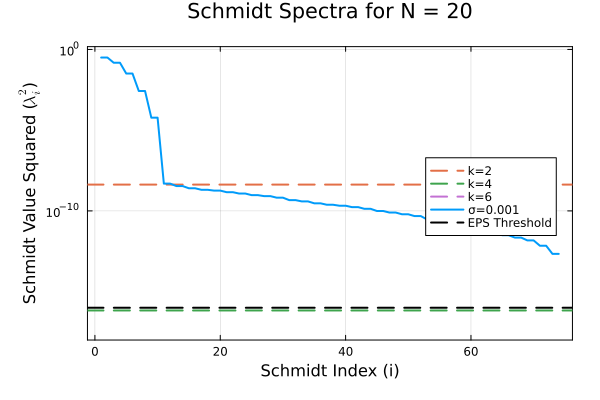

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\Schmidt_k_bands.png"

In [323]:

chosen_N = 20
disorder_sigma = 1e-3
target_trunc = 1e-16
c_leakage = 0.9


p1 = plot(
    title = "Schmidt Spectra for N = $chosen_N",
    xlabel = "Schmidt Index (i)",
    ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
    legend = :right,
    yscale = :log10,
    ylims = (1e-18, 1.5), 
    grid = true,
    framestyle = :box,
    size = (600, 400),
    margin = 5 * Plots.mm
)

disordered_spectra = Float64[]

if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], disorder_sigma)
    data_subset = all_data[target_trunc][disorder_sigma]
    idx_dis = findfirst(==(chosen_N), data_subset["N_range"])
    
    if !isnothing(idx_dis)
        disordered_spectra = data_subset["spectra_avg"][idx_dis, :]
    end
end

x_dis, y_dis = get_sorted_data_truncated(disordered_spectra, target_trunc)

if disorder_sigma > 0.0
    levs = get_corrected_k_levels(chosen_N, disorder_sigma, c_leakage)
    
    hline!(p1, [levs.k2], label = "k=2", linestyle = :dash, color = 2, linewidth = 2)
    hline!(p1, [levs.k4], label = "k=4", linestyle = :dash, color = 3, linewidth = 2)
    hline!(p1, [levs.k6], label = "k=6", linestyle = :dash, color = 4, linewidth = 2)
end

if !isempty(x_dis)
    plot!(p1, x_dis, y_dis, label = "σ=$disorder_sigma", color = 1, linewidth = 2)
end

hline!(p1, [target_trunc], label = "EPS Threshold", linestyle = :dash, linecolor = :black, linewidth = 2)

display(p1)

mkpath(joinpath(@__DIR__, "images_report"))
savefig(p1, joinpath(@__DIR__, "images_report", "Schmidt_k_bands.png"))

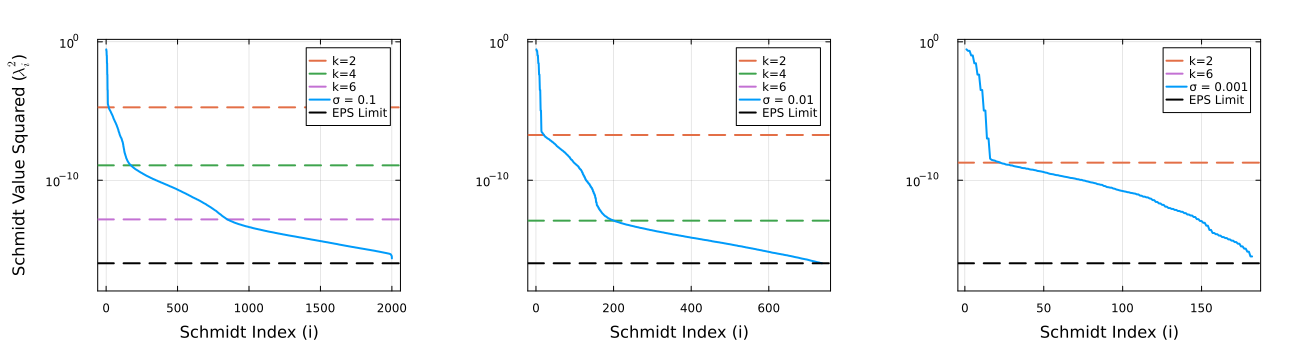

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\Schmidt_k_bands_grid.png"

In [322]:

chosen_N = 30
target_sigmas = [1e-3, 1e-2, 1e-1] 
target_trunc = 1e-16
c_leakage = 0.9

subplots = []

for (i, disorder_sigma) in enumerate(sort(target_sigmas, rev = true))
    
    y_label_text = i == 1 ? L"Schmidt Value Squared ($\lambda_{i}^{2}$)" : ""
    
    p = plot(
        # title = "σ = $disorder_sigma",
        xlabel = "Schmidt Index (i)",
        ylabel = y_label_text,
        legend = :topright,
        yscale = :log10,
        ylims = (1e-18, 1.5), 
        size = (800, 400),
        margin = 5 * Plots.mm,
        grid = true,
        framestyle = :box
    )

    disordered_spectra = Float64[]

    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], disorder_sigma)
        data_subset = all_data[target_trunc][disorder_sigma]
        idx_dis = findfirst(==(chosen_N), data_subset["N_range"])
        
        if !isnothing(idx_dis)
            disordered_spectra = data_subset["spectra_avg"][idx_dis, :]
        end
    end

    x_dis, y_dis = get_sorted_data_truncated(disordered_spectra, target_trunc)

    if disorder_sigma > 0.0
        levs = get_corrected_k_levels(chosen_N, disorder_sigma, c_leakage)
        
        hline!(p, [levs.k2], label = "k=2", linestyle = :dash, color = 2, linewidth = 2)
        if disorder_sigma > 1e-3

            hline!(p, [levs.k4], label = "k=4", linestyle = :dash, color = 3, linewidth = 2)
        end
        hline!(p, [levs.k6], label = "k=6", linestyle = :dash, color = 4, linewidth = 2)
    end

    if !isempty(x_dis)
        plot!(p, x_dis, y_dis, label = "σ = $disorder_sigma", color = 1, linewidth = 2)
    end

    hline!(p, [target_trunc], label = "EPS Limit", linestyle = :dash, linecolor = :black, linewidth = 2)
    
    push!(subplots, p)
end

grid_plot = plot(
    subplots..., 
    layout = (1, 3), 
    size = (1300, 350), 
    margin = 8Plots.mm,
    # plot_title = "Schmidt Spectra for N = $chosen_N across Disordered States",
    # plot_titlevspan = 0.1 # Gives the main title some breathing room
)

display(grid_plot)

savefig(grid_plot, joinpath(@__DIR__, "images_report", "Schmidt_k_bands_grid.png"))

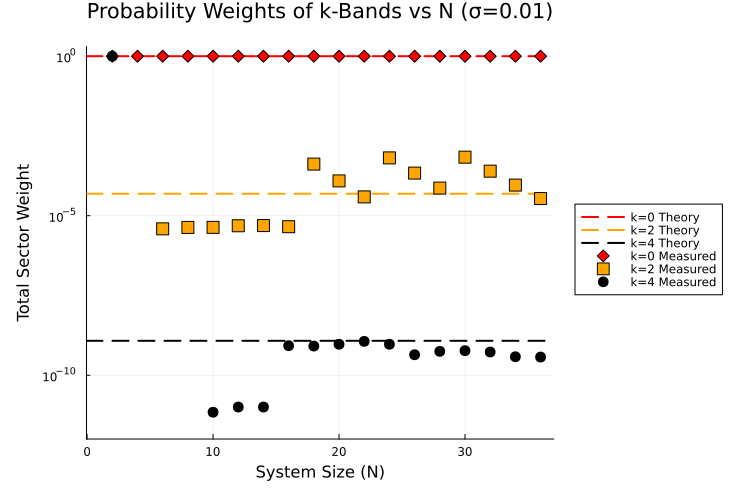

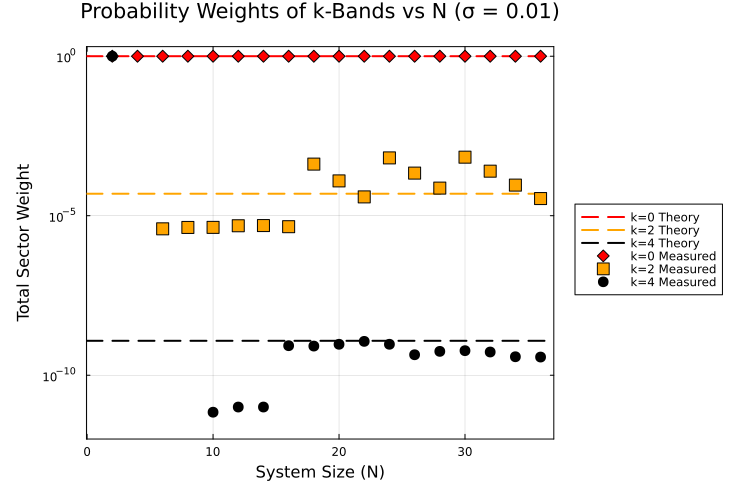

In [ ]:

disorder_sigma = 1e-2
target_trunc = 1e-16
c_leakage = 0.7

function get_theory_params(N, σ, c)
    # Weights follow the expansion terms (c*σ)^k / (k/2)!
    w = (1.0, (c * σ)^2, (c * σ)^4 / 2.0)
    tw = sum(w)
    
    # Total probability weights W_k, which are theoretically independent of N
    W = w ./ tw
    
    # Expected level heights L_k, which shift downwards as N increases
    # Manual degeneracy functions are replaced with the built-in binomial(N, k)
    L = (W[1] / binomial(N, 0), W[2] / binomial(N, 2), W[3] / binomial(N, 4))
    
    return W, L
end


data_sub = all_data[target_trunc][disorder_sigma]
N_range = data_sub["N_range"]
spectra_matrix = data_sub["spectra_avg"]

valid_N = Float64[]
measured = (W0 = Float64[], W2 = Float64[], W4 = Float64[])

for (idx, N) in enumerate(N_range)
    s_vals = sort(filter(x -> x > target_trunc, spectra_matrix[idx, :]), rev = true)
    isempty(s_vals) && continue
    
    W_theory, L_theory = get_theory_params(Int(N), disorder_sigma, c_leakage)
    
    # Integration boundaries are midpoints between shelf heights in log-space
    # These delineate the different k-sectors within the disordered spectrum
    b02 = sqrt(L_theory[1] * L_theory[2])
    b24 = sqrt(L_theory[2] * L_theory[3])
    
    push!(valid_N, N)
    
    # Sum the weights in each sector using generator expressions
    push!(measured.W0, sum(v for v in s_vals if v > b02))
    push!(measured.W2, sum(v for v in s_vals if b24 < v <= b02))
    push!(measured.W4, sum(v for v in s_vals if v <= b24))
end

p2 = plot(
    title = "Probability Weights of k-Bands vs N (σ = $disorder_sigma)",
    xlabel = "System Size (N)",
    ylabel = "Total Sector Weight",
    yscale = :log10,
    ylims = (1e-12, 2.0),
    legend = :outerright,
    grid = true,
    framestyle = :box,
    size = (750, 500),
    margin = 5 * Plots.mm
)

W_ref, _ = get_theory_params(Int(valid_N[1]), disorder_sigma, c_leakage)

hline!(p2, [W_ref[1]], label = "k=0 Theory", color = :red, linewidth = 2, linestyle = :dash)
hline!(p2, [W_ref[2]], label = "k=2 Theory", color = :orange, linewidth = 2, linestyle = :dash)
hline!(p2, [W_ref[3]], label = "k=4 Theory", color = :black, linewidth = 2, linestyle = :dash)

scatter!(p2, valid_N, measured.W0, label = "k=0 Measured", marker = :diamond, color = :red, markersize = 6)
scatter!(p2, valid_N, measured.W2, label = "k=2 Measured", marker = :square, color = :orange, markersize = 6)
scatter!(p2, valid_N, measured.W4, label = "k=4 Measured", marker = :circle, color = :black, markersize = 6)

display(p2)

# made up data

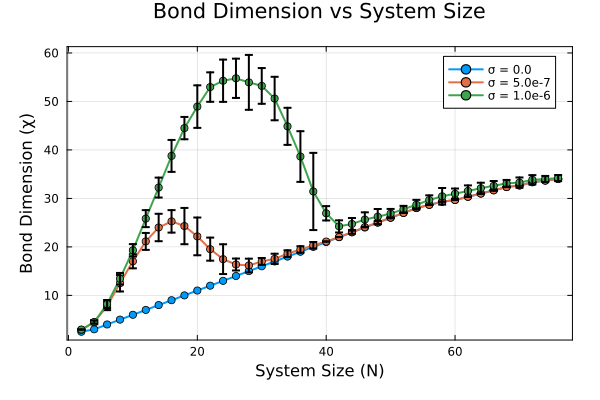

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\bd_dis_smoothed.png"

In [286]:
function moving_average(data, window_size::Int)
    n = length(data)
    smoothed = similar(data, Float64)
    half_window = window_size ÷ 2
    for i in 1:n
        start_idx = max(1, i - half_window)
        end_idx = min(n, i + half_window)
        smoothed[i] = sum(data[start_idx:end_idx]) / (end_idx - start_idx + 1)
    end
    return smoothed
end

target_sigmas = [0.0, 5e-7, 1e-6] 
target_trunc = 1e-16
max_N = 76

window_size = 3 

p_bd = plot(
    title = "Bond Dimension vs System Size",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topright,    
    grid=true,
    framestyle=:box,
    size = (600, 400),
    margin = 5Plots.mm
)

for σ in target_sigmas
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        bond_dims_full = data["avg_arr"]
        err_arr_full = data["err_arr"]
        
        mask = (bond_dims_full .> 0) .& (N_full .<= max_N)
        
        N_vals = N_full[mask]
        bond_dims = bond_dims_full[mask]
        
        if σ == 0.0
            err_bars = nothing
        else
            err_bars = err_arr_full[mask]
        end

        smoothed_bond_dims = moving_average(bond_dims, window_size)

        plot!(p_bd, N_vals, smoothed_bond_dims, 
            yerror = err_bars,
            label = "σ = $(σ)", 
            marker = :circle, 
            linewidth = 2,)


    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_bd)
savefig(p_bd, joinpath("images_report", "bd_dis_smoothed.png"))

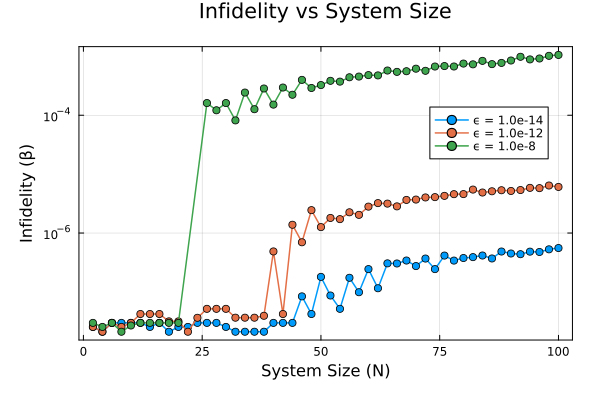

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\infid_vs_system_size_clean_interpolated.png"

In [287]:


function interpolate_missing_data(y_vals)
    y_new = copy(y_vals) 
    n = length(y_vals)
    
    for i in 1:n
        if y_vals[i] <= 0.0
            valid_neighbours = Float64[]
            
            for j in max(1, i-2):min(n, i+2)
                if j != i && y_vals[j] > 0.0
                    push!(valid_neighbours, y_vals[j])
                end
            end
            
            if !isempty(valid_neighbours)
                y_new[i] = mean(valid_neighbours)
            end
        end
    end
    return y_new
end

interpolated_infid_data = Dict{Float64, Dict{String, Any}}()
target_truncs = [1e-14, 1e-12, 1e-8]

for trunc in target_truncs
    N_vals, beta_vals = get_clean_infidelity_data(clean_fid_data, trunc)
    
    if !isnothing(N_vals)
        beta_vals_interpolated = interpolate_missing_data(beta_vals)
        
        interpolated_infid_data[trunc] = Dict(
            "N_vals" => N_vals,
            "beta_vals" => beta_vals_interpolated
        )
    else
        println("Warning: Data not found for Trunc = $trunc")
    end
end

p_infid_avg = plot(
    title = "Infidelity vs System Size",
    xlabel = "System Size (N)",
    ylabel = "Infidelity (β)",
    legend = (0.8, 0.75), 
    yscale = :log10, 
    grid = true,
    framestyle = :box,
    size = (600, 400),
    margin = 5 * Plots.mm
)

for trunc in target_truncs
    if haskey(interpolated_infid_data, trunc)
        data = interpolated_infid_data[trunc]
        N_vals = data["N_vals"]
        beta_vals = data["beta_vals"]
        
        valid_mask = beta_vals .> 1e-15
        
        if any(valid_mask)
            plot!(
                p_infid_avg, 
                N_vals[valid_mask], 
                beta_vals[valid_mask], 
                label = "ϵ = $(trunc)", 
                marker = :circle, 
                markersize = 4,
                linewidth = 1.5
            )
        else
            println("Note: Infidelity is effectively 0.0 for all N at Trunc = $trunc")
        end
    end
end

display(p_infid_avg)
savefig(p_infid_avg, joinpath(@__DIR__, "images_report", "infid_vs_system_size_clean_interpolated.png"))